In [93]:
import argparse
import os
import numpy as np
from Bio import Phylo
import sys
import os
import copy
import math
import json
import pandas as pd
import matplotlib.pyplot as plt

# Add parent directory to sys.path
sys.path.append(os.path.abspath(".."))
import importlib
importlib.reload(sys.modules['simulation_utils'])
from simulation_utils import *





def read_interaction_matrix(csv_file, host_tree_file, virus_tree_file):
    """
    Read host-virus interaction matrix CSV and reorder according to tree leaves.
    Treat viruses as parasites.
    
    Returns:
        cell_state: dict with keys (virus, host) -> 0/1
        host_tree: Bio.Phylo tree object
        virus_tree: Bio.Phylo tree object
    """

    # Load trees
    host_tree = Phylo.read(host_tree_file, "newick")
    virus_tree = Phylo.read(virus_tree_file, "newick")

    # Get leaf order
    host_order = [t.name for t in host_tree.get_terminals()]
    virus_order = [t.name for t in virus_tree.get_terminals()]

    print(f"Number of hosts in tree: {len(host_order)}")
    print(f"Number of viruses in tree: {len(virus_order)}")

    # Load interaction matrix CSV
    df = pd.read_csv(csv_file, index_col=0)  # assuming rows=viruses, columns=hosts
    # Ensure names match the expected tree leaf names
    df = df.loc[df.index.intersection(virus_order), df.columns.intersection(host_order)]

    # Reorder according to tree leaves
    df = df.reindex(index=virus_order, columns=host_order, fill_value=0)

    # Build cell_state dictionary
    cell_state = {}
    for virus in virus_order:
        for host in host_order:
            cell_state[(virus, host)] = int(df.at[virus, host])

    return cell_state, host_tree, virus_tree






def matrix_builder(out, r01_h, r10_h, r01_p, r10_p):
    # Build weight matrices for each parasite’s host tree
    host_W_matrices = []
    for t in out["host_trees"]:
        W, nodes = build_weight_matrix(t, r01_h, r10_h)
        host_W_matrices.append((W, nodes))

    # Build weight matrices for each host’s parasite tree
    par_W_matrices = []
    for t in out["par_trees"]:
        W, nodes = build_weight_matrix(t, r01_p, r10_p)
        par_W_matrices.append((W, nodes))

    # Flip cost matrix
    flip_cost_matrix = build_flip_cost_matrix(len(out["par_leaves"]), len(out["host_leaves"]), cost=1.0)
    return host_W_matrices, par_W_matrices, flip_cost_matrix


In [27]:
outdir = "experiments"
association_csv = "interaction_matrix_tree_leaves_beta_only.csv"
host_tree = "virion_bat_cov_output/trees/hosts_tree.newick"
virus_tree = "virion_bat_cov_output/trees/viruses_tree_beta_only.newick"


os.makedirs(outdir, exist_ok=True)

# Read associations + trees
cell_state, base_host_tree, base_par_tree = read_interaction_matrix(
    association_csv, host_tree, virus_tree
)

base_host_tree = rescale_tree(base_host_tree)
base_par_tree = rescale_tree(base_par_tree)

host_leaves = [t.name for t in base_host_tree.get_terminals()]
par_leaves = [t.name for t in base_par_tree.get_terminals()]

out = {
    "host_trees": [copy.deepcopy(base_host_tree) for _ in range(len(par_leaves))],
    "par_trees": [copy.deepcopy(base_par_tree) for _ in range(len(host_leaves))],
    "cell_state": cell_state,
    "host_leaves": host_leaves,
    "par_leaves": par_leaves
}

# Build the matrix
mat, parasites, hosts = get_interaction_matrix(out)

# Save the matrix visualization
plot_matrix(mat, parasites, hosts, filename=os.path.join(outdir, "original_matrix_beta_only.png"))







Number of hosts in tree: 231
Number of viruses in tree: 22
Matrix saved as experiments/original_matrix_beta_only.png


In [83]:
# Load taxonomy and benchmark data
host_tax = pd.read_csv("taxonomy_host.csv", dtype=str).fillna("")
virus_tax = pd.read_csv("taxonomy_virus.csv", dtype=str).fillna("")
betacov = pd.read_csv("BinaryWebsite.csv", dtype=str).fillna("")


# Normalize text columns (case-insensitive matching)
for df in [host_tax, virus_tax, betacov]:
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip().str.lower()


# Deduplicate taxonomy files by ID
host_tax = host_tax.drop_duplicates("HostTaxID")
virus_tax = virus_tax.drop_duplicates("VirusTaxID")

# Build lookup dicts
host_lookup = dict(zip(host_tax["HostTaxID"], host_tax["Host"]))
virus_lookup = dict(zip(virus_tax["VirusTaxID"], virus_tax["VirusGenus"]))
betacov_hosts_set = set(betacov["Sp"])
virion_betacov_hosts_id = [h for h in hosts if host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set]
betacov_true_hosts = set(betacov.loc[betacov["Ensemble"] == "true +", "Sp"])
betacov_negative_hosts = set(betacov.loc[betacov["Ensemble"] == "false -", "Sp"])
betacov_suspected_hosts = set(betacov.loc[betacov["Ensemble"] == "suspected", "Sp"])
betacov_unlikely_hosts = set(betacov.loc[betacov["Ensemble"] == "unlikely", "Sp"])



# --- Define which columns map to which models ---
model_columns = {
    "ensemble": "Ensemble",
    "model1": "Trait.1",
    "model2": "Trait.2",
    "model3": "Trait.3",
    "model4": "Hybrid",
    "model5": "Network.1",
    "model6": "Network.2",
    "model7": "Network.3",
    "model8": "Network.4",
}

# --- Extract truth sets for each model automatically ---
truth_sets = {}
for model_name, col in model_columns.items():
    truth_sets[model_name] = {
        "true": set(betacov.loc[betacov[col] == "true +", "Sp"]),
        "suspected": set(betacov.loc[betacov[col] == "suspected", "Sp"]),
        "negative": set(betacov.loc[betacov[col] == "false -", "Sp"]) | set(betacov.loc[betacov[col] == "", "Sp"]),
        "unlikely": set(betacov.loc[betacov[col] == "unlikely", "Sp"]),
    }


categories = ["true", "suspected", "negative", "unlikely"]

virion_sets = {}
for model_name, sets in truth_sets.items():
    virion_sets[model_name] = {}
    for category in categories:
        sp_set = sets[category]
        virion_sets[model_name][category] = [
            h for h in hosts if host_lookup.get(h.split("_", 1)[1], "") in sp_set
        ]
    virion_sets[model_name]["precision"] = len(virion_sets[model_name]["true"])/(len(virion_sets[model_name]["true"])+len(virion_sets[model_name]["suspected"])) if (len(virion_sets[model_name]["true"])+len(virion_sets[model_name]["suspected"]))>0 else 0
    virion_sets[model_name]["recall"] = len(virion_sets[model_name]["true"])/(len(virion_sets[model_name]["true"])+len(virion_sets[model_name]["negative"])) if (len(virion_sets[model_name]["true"])+len(virion_sets[model_name]["negative"]))>0 else 0


# --- Map VIRION hosts into each model’s categories ---



# Example: check counts becareful about precision/recall calculation
for model_name in virion_sets:
    print(f"\n{model_name.upper()} counts:")
    for category, hs in virion_sets[model_name].items():
        if category in ["precision", "recall"]:
            continue
        print(f"  {category}: {len(hs)}")






print("Betacov hosts evaluation:")
print(f"  True +  : {len(betacov_true_hosts)} ")
print(f"  False - : {len(betacov_negative_hosts)} ")
print(f"  Suspected: {len(betacov_suspected_hosts)}")
print(f"  Unlikely : {len(betacov_unlikely_hosts)} ")


# print virion model precisions and recalls
for model_name, sets in virion_sets.items():
    precision = sets["precision"]
    recall = sets["recall"]
    print(f"{model_name.upper()} - Precision: {precision:.3f}, Recall: {recall:.3f}")




ENSEMBLE counts:
  true: 59
  suspected: 77
  negative: 3
  unlikely: 48

MODEL1 counts:
  true: 58
  suspected: 101
  negative: 4
  unlikely: 24

MODEL2 counts:
  true: 58
  suspected: 80
  negative: 4
  unlikely: 45

MODEL3 counts:
  true: 57
  suspected: 113
  negative: 10
  unlikely: 7

MODEL4 counts:
  true: 58
  suspected: 31
  negative: 5
  unlikely: 93

MODEL5 counts:
  true: 44
  suspected: 68
  negative: 75
  unlikely: 0

MODEL6 counts:
  true: 62
  suspected: 7
  negative: 56
  unlikely: 62

MODEL7 counts:
  true: 56
  suspected: 66
  negative: 62
  unlikely: 3

MODEL8 counts:
  true: 58
  suspected: 65
  negative: 60
  unlikely: 4
Betacov hosts evaluation:
  True +  : 72 
  False - : 7 
  Suspected: 371
  Unlikely : 666 
ENSEMBLE - Precision: 0.434, Recall: 0.952
MODEL1 - Precision: 0.365, Recall: 0.935
MODEL2 - Precision: 0.420, Recall: 0.935
MODEL3 - Precision: 0.335, Recall: 0.851
MODEL4 - Precision: 0.652, Recall: 0.921
MODEL5 - Precision: 0.393, Recall: 0.370
MODEL6 -

In [4]:
def plot_matrix_betacov_ensemble(matrix, parasites, hosts,
                                 virus_lookup, host_lookup, betacov,
                                 filename="betacov_ensemble_matrix.png"):
    """
    Plot matrix restricted to betacoronaviruses and hosts in the ensemble dataset.
    Column shading based on Ensemble status.
    """
    # Filter rows (betacoronaviruses)
    betacov_parasites = [p for p in parasites if virus_lookup.get(p.split("_",1)[1], "") == "betacoronavirus"]
    
    # Filter columns (hosts in ensemble dataset)
    betacov_hosts_set = set(betacov["Sp"])
    betacov_hosts_id = [h for h in hosts if host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set]

    # Slice matrix
    p_idx = [parasites.index(p) for p in betacov_parasites]
    h_idx = [hosts.index(h) for h in betacov_hosts_id]
    submat = matrix[np.ix_(p_idx, h_idx)]
    print(f"Filtered matrix size: {submat.shape} (parasites: {len(betacov_parasites)}, hosts: {len(betacov_hosts_id)})")

    # Column shading based on Ensemble
    true_hosts = set(betacov.loc[betacov["Ensemble"] == "true +", "Sp"])
    false_hosts = set(betacov.loc[betacov["Ensemble"] == "false -", "Sp"])
    col_colors = []
    for h in hosts:
        host_name = host_lookup.get(h.split("_",1)[1], "")
        if host_name in true_hosts:
            col_colors.append("green")
        elif host_name in false_hosts:
            col_colors.append("orange")
        else:
            col_colors.append(None)

    n_rows, n_cols = matrix.shape
    fig, ax = plt.subplots(figsize=(max(6, n_cols*0.4), max(6, n_rows*0.4)))

    # Draw column background shading
    for j, color in enumerate(col_colors):
        if color:
            ax.add_patch(plt.Rectangle((j-0.5, -0.5), 1, n_rows, facecolor=color, alpha=0.5, edgecolor=None, zorder=1))

    # Draw matrix cells
    for i in range(n_rows):
        for j in range(n_cols):
            cell_color = "red" if matrix[i,j] == 1 else "blue"
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, facecolor=cell_color, edgecolor=None, linewidth=0.2, zorder=0))

    # Axes and labels
    ax.set_xlim(-0.5, n_cols-0.5)
    ax.set_ylim(n_rows-0.5, -0.5)
    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(n_rows))
    ax.set_xticklabels(hosts, rotation=90, fontsize=6)
    ax.set_yticklabels(parasites, fontsize=6)

    # Grid
    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.title("Betacoronavirus vs Ensemble Hosts")
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    print("Saved ensemble-focused matrix to", filename)
def plot_corrupt_out(out_corrupt, hidden_cells, parasites, hosts, filtered_hosts,
                     filename="corrupted_matrix_plot.png"):
    """
    Plot corrupted matrix restricted to hosts in betacov true+ or false-.
    Highlight hidden/erased cells (yellow), other cells red/blue as usual.
    """
    # ----------------------------
    # Get betacov host sets
    # ----------------------------

    # Build submatrix
    submat = np.zeros((len(parasites), len(filtered_hosts)), dtype=int)
    for i, virus in enumerate(parasites):
        for j, host in enumerate(filtered_hosts):
            submat[i, j] = out_corrupt["cell_state"][(virus, host)]

    # Build erased cells list (yellow)
    erased_cells = []
    hidden_set = set(hidden_cells)
    for i, virus in enumerate(parasites):
        for j_idx, host in enumerate(filtered_hosts):
            if (virus, host) in hidden_set:
                erased_cells.append((i, j_idx))

    # ----------------------------
    # Plotting
    # ----------------------------
    n_rows, n_cols = submat.shape
    fig, ax = plt.subplots(figsize=(max(6, n_cols*0.4), max(6, n_rows*0.4)))

    # Draw cells
    for i in range(n_rows):
        for j in range(n_cols):
            color = "red" if submat[i,j]==1 else "blue"
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, facecolor=color, edgecolor=None, linewidth=0.2))

    # Highlight erased cells
    for i, j in erased_cells:
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, facecolor="yellow", alpha=0.6, edgecolor=None, linewidth=0.5))


    # Axes and labels
    ax.set_xlim(-0.5, n_cols-0.5)
    ax.set_ylim(n_rows-0.5, -0.5)
    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(n_rows))
    ax.set_xticklabels(filtered_hosts, rotation=90, fontsize=6)
    ax.set_yticklabels(parasites, fontsize=6)

    # Grid lines
    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.title("Corrupted Matrix (yellow = erased cells)")
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    print("Saved corrupted matrix plot to", filename)



Filtered matrix size: (22, 187) (parasites: 22, hosts: 187)


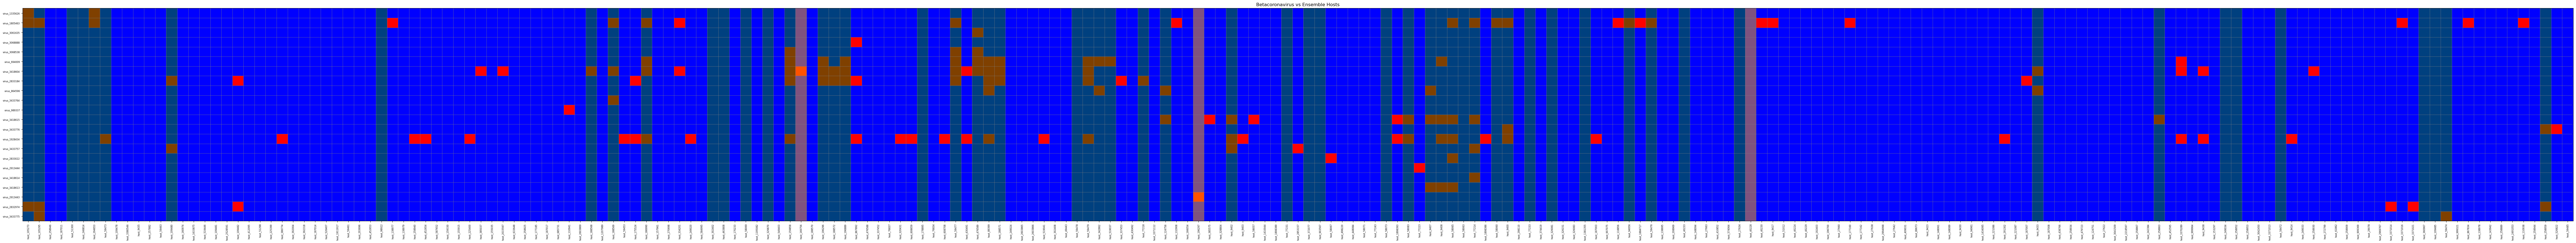

Saved ensemble-focused matrix to experiments/original_matrix_beta_only_betacov_hosts.png


In [5]:
plot_matrix_betacov_ensemble(mat, parasites, hosts,
                             virus_lookup=virus_lookup,
                             host_lookup=host_lookup,
                             betacov=betacov,
                             filename=os.path.join(outdir, "original_matrix_beta_only_betacov_hosts.png"))


In [6]:
out_original = out.copy()  # Keep original for each run

In [98]:
out_corrupt = out_original.copy()
hidden_cells = []
# for virus in parasites:
#     for host in hosts:
#         if out_corrupt["cell_state"][(virus, host)] == 1 and host in betacov_true_hosts_id:
#             hidden_cells.append((virus, host))
#             out_corrupt["cell_state"][(virus, host)] = 0
seed = 42
r01_p, r10_p, r01_h, r10_h = 0.5,0.5, 0.5, 0.5
# lambda_param = 0.9
lambda_param = 0.9  # IGNORE
host_W_matrices, par_W_matrices, flip_cost_matrix = matrix_builder(out_corrupt, r01_h, r10_h, r01_p, r10_p)


In [ ]:
plot_corrupt_out(out_corrupt, hidden_cells, parasites, hosts,
                 virion_betacov_hosts_id,
                 filename=os.path.join(outdir, "corrupted_matrix.png"))

In [99]:
def current_positive_hosts(cell_state, betacov, virion_sets):
    current = set()

    for (virus_id, host_id), val in cell_state.items():
        v = virus_id.split("_", 1)[1]
        h = host_id.split("_", 1)[1]
        host_name = host_lookup.get(h, "")
        virus_genus = virus_lookup.get(v, "")

        if val == 1 and virus_genus == "betacoronavirus":
            if host_name in betacov["Sp"].values:
                current.add(host_id)

    # ground sets
    gt_pos = set(virion_sets["ensemble"]["true"]) | set(virion_sets["ensemble"]["negative"])
    gt_neg = set(virion_sets["ensemble"]["suspected"]) | set(virion_sets["ensemble"]["unlikely"])

    # classification
    tp = list(current & gt_pos)
    fp = list(current & gt_neg)
    fn = list(gt_pos - current)
    tn = list(gt_neg - current)

    # print(f"Predicted betacoronavirus hosts: {len(current)}")
    print(f"TP={len(tp)}, FP={len(fp)}, FN={len(fn)}, TN={len(tn)}")

    return tp, tn, fp, fn

    

In [100]:
# ---------------------------
# Step 2: Run network cut recovery on corrupted input
# ---------------------------

print ("before flip")
print (current_positive_hosts(out_original["cell_state"], betacov, virion_sets))

cut_result = solve_network_cut(out_corrupt, 
                               host_W_matrices=host_W_matrices, 
                               par_W_matrices=par_W_matrices,
                               flip_cost_matrix=flip_cost_matrix,
                               lambda_param=lambda_param)





new_mat = cut_result["new_matrix"]
new_cell_state = cut_result["new_cell_state"]
flips = cut_result["flips"]

highlight_flipped = {"flipped": [(p, h) for p, h, old, new in flips]}
print(f"Number of flips performed: {len(flips)}")
for p, h, old, new in flips:
    print(f"Cell ({p},{h}): {old} -> {new}")

print ("after flip at lambda =", lambda_param)
print (current_positive_hosts(new_cell_state, betacov, virion_sets))


cost_matrix = np.array([[0, 1],
                        [1, 0]])  # symmetric 0↔1 cost

host_root_states = {}
for h in hosts:
    root_state = find_state_of_root_using_sankoff(out["par_trees"][0], {p: cut_result["new_cell_state"][(p,h)] for p in parasites}, cost_matrix)
    host_root_states[h] = root_state

# Extract predicted positive hosts
current = {h for h, s in host_root_states.items() if s == 1 and host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set}

# find true positives, false positives, etc.
gt_pos = set(virion_sets["ensemble"]["true"]) | set(virion_sets["ensemble"]["negative"])
gt_neg = set(virion_sets["ensemble"]["suspected"]) | set(virion_sets["ensemble"]["unlikely"])
tp = list(current & gt_pos)
fp = list(current & gt_neg)
fn = list(gt_pos - current)
tn = list(gt_neg - current)
print(f"Predicted betacoronavirus hosts in root level after flip: {len(current)}")
print(f"TP={len(tp)}, FP={len(fp)}, FN={len(fn)}, TN={len(tn)}")


# --- Predicted positives: hosts whose root state = 1 and appear in betacov dataset ---
host_root_states = cut_result["root_states"]
current = {h for h, s in host_root_states.items() if s == 1 and host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set}


# --- Compute confusion matrix sets ---
tp = current & gt_pos
fp = current & gt_neg
fn = gt_pos - current
tn = gt_neg - current

# --- Metrics ---
precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) else 0
recall = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) else 0

print (f"At root level after flip using algo: TP={len(tp)}, FP={len(fp)}, FN={len(fn)}, TN={len(tn)}")

# ---------------------------
# Step 3: Save recovered matrix with algorithm flips
# ---------------------------
plot_matrix(new_mat, parasites, hosts,
            filename=os.path.join(outdir, "flipped_matrix_beta_only.png"),
            highlight=highlight_flipped)






# inside main(), after you have flips and hidden_cells
# metrics = compute_metrics(hidden_cells, flips)
# print("Metrics:", metrics)






before flip
TP=37, FP=33, FN=25, TN=92
(['host_9433', 'host_342862', 'host_196296', 'host_188568', 'host_59479', 'host_105295', 'host_59473', 'host_89399', 'host_294653', 'host_476589', 'host_9407', 'host_109480', 'host_519037', 'host_58060', 'host_188571', 'host_77214', 'host_58065', 'host_58083', 'host_188572', 'host_196297', 'host_59474', 'host_196889', 'host_105273', 'host_124756', 'host_59477', 'host_159858', 'host_9402', 'host_258959', 'host_186990', 'host_169756', 'host_258863', 'host_9400', 'host_59476', 'host_77218', 'host_9408', 'host_188569', 'host_94956'], ['host_249033', 'host_89673', 'host_430492', 'host_257882', 'host_148061', 'host_258889', 'host_909369', 'host_1410044', 'host_1207989', 'host_2491053', 'host_177185', 'host_907075', 'host_27663', 'host_225399', 'host_221087', 'host_221086', 'host_109478', 'host_392318', 'host_999964', 'host_94961', 'host_326083', 'host_302408', 'host_452653', 'host_155915', 'host_27642', 'host_187014', 'host_249024', 'host_188570', 'host

In [101]:


# print ("Virion betacov hosts evaluation:")
# print(f"  True +  : {len(virion_betacov_true_hosts)} ")
# print(f"  False - : {len(virion_betacov_negative_hosts)} ")
# print(f"  Suspected: {len(virion_betacov_suspected_hosts)}")
# print(f"  Unlikely : {len(virion_betacov_unlikely_hosts)} ")


# Now check flips
results = []
for virus_id, host_id, old, new in flips:   # flips = cut_result["flips"]
    v = virus_id.split("_", 1)[1]
    h = host_id.split("_", 1)[1]

    host_name = host_lookup.get(h, "")
    virus_genus = virus_lookup.get(v, "")

    if not host_name:
        status = "host_unknown"
    elif not virus_genus:
        # print (f"Warning: For Virus ID {v} Genus not found in taxonomy.")
        status = "virus_unknown"
    else:
        if virus_genus == "betacoronavirus":
            if host_name in betacov_true_hosts:
                status = "correct"
            elif host_name in betacov_suspected_hosts:
                status = "incorrect_but_suspected"
            elif host_name in betacov_negative_hosts:
                status = "incorrect_but_negative"
            elif host_name in betacov_unlikely_hosts:
                status = "incorrect_but_unlikely"
            else:
                status = "host not in dataset"
        else:
            status = "non_betacoronavirus"

    results.append({
        "virus_id": v,
        "host_id": h,
        "virus_genus": virus_genus,
        "host_name": host_name,
        "status": status
    })

results_df = pd.DataFrame(results)

# Summary breakdown
#  only show correct, incorrect_but_suspected, incorrect_but_negative, incorrect_but_unlikely
results_df = results_df[results_df["status"].isin([
    "correct", "incorrect_but_suspected", "incorrect_but_negative", "incorrect_but_unlikely"
])]
print(results_df["status"].value_counts())


# --- Unique host-level summary ---
# Consider betacoronavirus predictions only
my_betacov_predictions = results_df[
    results_df["virus_genus"] == "betacoronavirus"
]
predicted_hosts = my_betacov_predictions["host_name"].unique()

# Hosts predicted as "potential bearers"
predicted_true_hosts = my_betacov_predictions[
    my_betacov_predictions["status"]=="correct"
]["host_name"].unique()
predicted_negative_hosts = my_betacov_predictions[
    my_betacov_predictions["status"]=="incorrect_but_negative"
]["host_name"].unique()
predicted_suspected_hosts = my_betacov_predictions[
    my_betacov_predictions["status"]=="incorrect_but_suspected"
]["host_name"].unique()
predicted_unlikely_hosts = my_betacov_predictions[
    my_betacov_predictions["status"]=="incorrect_but_unlikely"
]["host_name"].unique()

print(f"Number of unique predicted true betacoronavirus hosts: {len(predicted_true_hosts)}")
print(f"Number of unique predicted negative betacoronavirus hosts: {len(predicted_negative_hosts)}")
print(f"Number of unique predicted suspected betacoronavirus hosts: {len(predicted_suspected_hosts)}")
print(f"Number of unique predicted unlikely betacoronavirus hosts: {len(predicted_unlikely_hosts)}")
print("Total betacoronavirus hosts predicted:", len(predicted_hosts))


precision = (len(predicted_true_hosts) + len(predicted_negative_hosts))/len(predicted_hosts)
print(f"Precision (true + negative / total predicted): {precision:.3f}")
recall = (len(predicted_true_hosts) + len(predicted_negative_hosts))/(len(truth_sets["ensemble"]["true"])+len(truth_sets["ensemble"]["negative"]))
print(f"Recall (true + negative / total actual): {recall:.3f}")
# print("Predicted true host set:", predicted_true_hosts)




# Save results
results_df.to_csv("flip_check_results.csv", index=False)


status
incorrect_but_suspected    77
correct                    44
incorrect_but_negative      7
Name: count, dtype: int64
Number of unique predicted true betacoronavirus hosts: 9
Number of unique predicted negative betacoronavirus hosts: 1
Number of unique predicted suspected betacoronavirus hosts: 10
Number of unique predicted unlikely betacoronavirus hosts: 0
Total betacoronavirus hosts predicted: 20
Precision (true + negative / total predicted): 0.500
Recall (true + negative / total actual): 0.127


In [102]:
lambda_values = np.linspace(0.1, 1.0, 100)  # for example, 10 values between 0.1 and 1.0
results_curve = []
virion_curve = []
results_curve_root_level = []
results_curve_root_level_algo = []

for lam in lambda_values:
    out_corrupt = out_original.copy()
    print (f"\nRunning network cut with lambda = {lam:.2f}")
    cut_result = solve_network_cut(
        out_corrupt,
        host_W_matrices=host_W_matrices,
        par_W_matrices=par_W_matrices,
        flip_cost_matrix=flip_cost_matrix,
        lambda_param=lam
    )
    flips = cut_result["flips"]
    new_cell_state = cut_result["new_cell_state"]
    tp,tn,fp,fn = current_positive_hosts(new_cell_state, betacov, virion_sets)

    virion_precision = (len(tp)) / (len(tp) + len(fp)) if (len(tp) + len(fp)) > 0 else 0.0
    virion_recall = (len(tp)) / (len(tp) + len(fn)) if (len(tp) + len(fn)) > 0 else 0.0


    # classify flips (same as in your code above)
    results = []
    for virus_id, host_id, old, new in flips:
        v = virus_id.split("_", 1)[1]
        h = host_id.split("_", 1)[1]
        host_name = host_lookup.get(h, "")
        virus_genus = virus_lookup.get(v, "")
        if not host_name or not virus_genus:
            continue
        if virus_genus == "betacoronavirus":
            if host_name in betacov_true_hosts:
                status = "correct"
            elif host_name in betacov_suspected_hosts:
                status = "incorrect_but_suspected"
            elif host_name in betacov_negative_hosts:
                status = "incorrect_but_negative"
            elif host_name in betacov_unlikely_hosts:
                status = "incorrect_but_unlikely"
            else:
                status = "host not in dataset"
            results.append({"host_name": host_name, "status": status})

    if len(results) == 0:
        continue
    results_df = pd.DataFrame(results)

    # filter only statuses of interest
    results_df = results_df[results_df["status"].isin([
        "correct", "incorrect_but_negative", "incorrect_but_suspected", "incorrect_but_unlikely"
    ])]

    # unique hosts
    betacov_predictions = results_df["host_name"].unique()
    predicted_true_hosts = results_df.loc[results_df["status"]=="correct", "host_name"].unique()
    predicted_negative_hosts = results_df.loc[results_df["status"]=="incorrect_but_negative", "host_name"].unique()

    # precision and recall
    if len(betacov_predictions) > 0:
        precision = (len(predicted_true_hosts) + len(predicted_negative_hosts)) / len(betacov_predictions)
    else:
        precision = 0.0
    denom = len(virion_sets["ensemble"]["true"]) + len(virion_sets["ensemble"]["negative"])
    recall = (len(predicted_true_hosts) + len(predicted_negative_hosts)) / denom if denom > 0 else 0.0

    results_curve.append({
        "lambda": lam,
        "precision": precision,
        "recall": recall,
        "n_predicted": len(betacov_predictions)
    })
    virion_curve.append({
        "lambda": lam,
        "precision": virion_precision,
        "recall": virion_recall,
        "n_predicted": len(tp) + len(fp)
    })

    cost_matrix = np.array([[0, 1],
                            [1, 0]])  # symmetric 0↔1 cost
    host_root_states = {}
    for h in hosts:
        root_state = find_state_of_root_using_sankoff(out["par_trees"][0], {p: cut_result["new_cell_state"][(p,h)] for p in parasites}, cost_matrix)
        host_root_states[h] = root_state
    current = {h for h, s in host_root_states.items() if s == 1 and host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set}
    gt_pos = set(virion_sets["ensemble"]["true"]) | set(virion_sets["ensemble"]["negative"])
    gt_neg = set(virion_sets["ensemble"]["suspected"]) | set(virion_sets["ensemble"]["unlikely"])
    tp_root = list(current & gt_pos)
    fp_root = list(current & gt_neg)
    fn_root = list(gt_pos - current)
    tn_root = list(gt_neg - current)
    print(f"At root level - TP={len(tp_root)}, FP={len(fp_root)}, FN={len(fn_root)}, TN={len(tn_root)}")
    virion_precision_root = (len(tp_root)) / (len(tp_root) + len(fp_root)) if (len(tp_root) + len(fp_root)) > 0 else 0.0
    virion_recall_root = (len(tp_root)) / (len(tp_root) + len(fn_root)) if (len(tp_root) + len(fn_root)) > 0 else 0.0
    results_curve_root_level.append({
        "lambda": lam,
        "precision": virion_precision_root,
        "recall": virion_recall_root,
        "n_predicted": len(tp_root) + len(fp_root)
    })

    current = cut_result["root_states"]
    current = {h for h, s in current.items() if s == 1 and host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set}
    tp_root_algo = list(current & gt_pos)
    fp_root_algo = list(current & gt_neg)
    fn_root_algo = list(gt_pos - current)
    tn_root_algo = list(gt_neg - current)
    print(f"At root level using algo - TP={len(tp_root_algo)}, FP={len(fp_root_algo)}, FN={len(fn_root_algo)}, TN={len(tn_root_algo)}")
    virion_precision_root_algo = (len(tp_root_algo)) / (len(tp_root_algo) + len(fp_root_algo)) if (len(tp_root_algo) + len(fp_root_algo)) > 0 else 0.0
    virion_recall_root_algo = (len(tp_root_algo)) / (len(tp_root_algo) + len(fn_root_algo)) if (len(tp_root_algo) + len(fn_root_algo)) > 0 else 0.0
    results_curve_root_level_algo.append({
        "lambda": lam,
        "precision": virion_precision_root_algo,
        "recall": virion_recall_root_algo,
        "n_predicted": len(tp_root_algo) + len(fp_root_algo)
    })

# convert to DataFrame
curve_df = pd.DataFrame(results_curve)
virion_curve_df = pd.DataFrame(virion_curve)
curve_root_df = pd.DataFrame(results_curve_root_level)
curve_root_df_algo = pd.DataFrame(results_curve_root_level_algo)
print(curve_df)
print(virion_curve_df)
print (curve_root_df)
print (curve_root_df_algo)



Running network cut with lambda = 0.10
TP=37, FP=33, FN=25, TN=92

Running network cut with lambda = 0.11
TP=37, FP=33, FN=25, TN=92

Running network cut with lambda = 0.12
TP=37, FP=33, FN=25, TN=92

Running network cut with lambda = 0.13
TP=37, FP=33, FN=25, TN=92

Running network cut with lambda = 0.14
TP=37, FP=33, FN=25, TN=92

Running network cut with lambda = 0.15
TP=37, FP=33, FN=25, TN=92

Running network cut with lambda = 0.15
TP=37, FP=33, FN=25, TN=92

Running network cut with lambda = 0.16
TP=37, FP=33, FN=25, TN=92

Running network cut with lambda = 0.17
TP=37, FP=33, FN=25, TN=92

Running network cut with lambda = 0.18
TP=37, FP=33, FN=25, TN=92

Running network cut with lambda = 0.19
TP=37, FP=33, FN=25, TN=92

Running network cut with lambda = 0.20
TP=37, FP=33, FN=25, TN=92

Running network cut with lambda = 0.21
TP=37, FP=33, FN=25, TN=92

Running network cut with lambda = 0.22
TP=37, FP=33, FN=25, TN=92

Running network cut with lambda = 0.23
TP=37, FP=33, FN=25, T

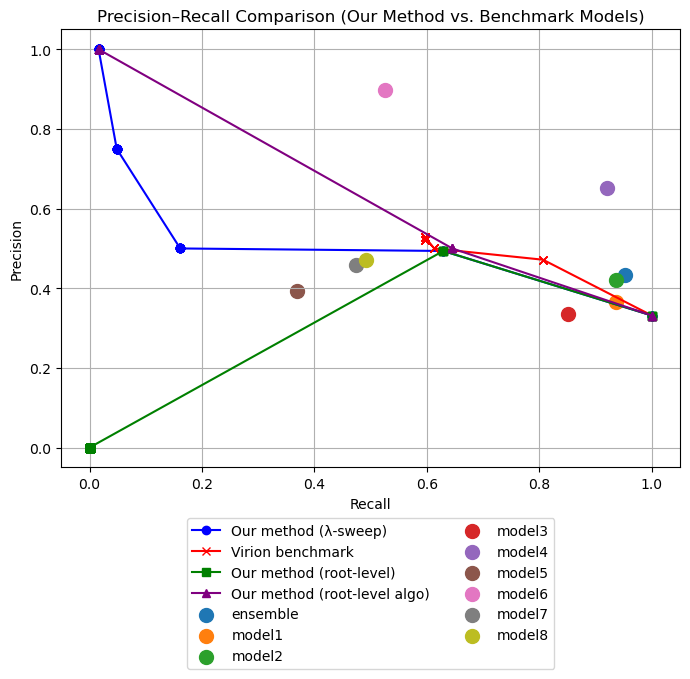

In [108]:
# --- Plot PR curve of your λ sweep ---
plt.figure(figsize=(7,7))

# sort curve_df by recall
curve_sorted = curve_df.sort_values("recall")
virion_curve_sorted = virion_curve_df.sort_values("recall")
curve_root_sorted = curve_root_df.sort_values("recall")
curve_root_sorted_algo = curve_root_df_algo.sort_values("recall")

plt.plot(curve_sorted["recall"], curve_sorted["precision"], marker="o",
         label="Our method (λ-sweep)", color="blue")
plt.plot(virion_curve_sorted["recall"], virion_curve_sorted["precision"], marker="x",
         label="Virion benchmark", color="red")
plt.plot(curve_root_sorted["recall"], curve_root_sorted["precision"], marker="s",
         label="Our method (root-level)", color="green")
plt.plot(curve_root_sorted_algo["recall"], curve_root_sorted_algo["precision"], marker="^",
         label="Our method (root-level algo)", color="purple")
# annotate λ values
# for i, row in curve_sorted.iterrows():
#     plt.text(row["recall"], row["precision"], f"{row['lambda']:.2f}",
#              fontsize=7, color="blue")

# --- Overlay other models ---
colors = plt.cm.tab10.colors  # nice palette
for i, (model_name, sets) in enumerate(virion_sets.items()):
    plt.scatter(sets["recall"], sets["precision"], label=model_name, color=colors[i % len(colors)], s=100)
# --- Final plot formatting ---
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Comparison (Our Method vs. Benchmark Models)")
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", ncol=2)
plt.tight_layout()
plt.grid(True)
plt.savefig(os.path.join(outdir, "precision_recall_curve.png"), dpi=300)

In [7]:
betacov["Ensemble"].value_counts()

Ensemble
unlikely     666
suspected    371
true +        72
false -        7
Name: count, dtype: int64

In [8]:
host_lookup.get("178895")

'rhinolophus creaghi'

In [16]:
def plot_matrix_betacov(matrix, parasites, hosts,
                        virus_lookup, host_lookup, betacov,
                        filename="betacov_matrix.png",
                        highlight=None):
    """
    Plot flipped matrix restricted to betacoronaviruses (rows) 
    and betacov hosts (columns), with transparent column shading.
    
    0 → blue, 1 → red, flipped → green, 
    column shading: true (light green), suspected (light orange)
    """
    # ----------------------------
    # Filter rows (viruses) by betacoronavirus genus
    # ----------------------------
    betacov_parasites = [p for p in parasites if virus_lookup.get(p.split("_",1)[1], "") == "betacoronavirus"]

    # ----------------------------
    # Filter cols (hosts) by betacov data
    # ----------------------------
    betacov_hosts_set = set(betacov["Sp"])
    filtered_hosts = [h for h in hosts if host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set]

    # Slice matrix
    p_idx = [parasites.index(p) for p in betacov_parasites]
    h_idx = [hosts.index(h) for h in filtered_hosts]
    submat = matrix[np.ix_(p_idx, h_idx)]
    print (f"Filtered matrix size: {submat.shape} (parasites: {len(betacov_parasites)}, hosts: {len(filtered_hosts)})")

    
    # ----------------------------
    # Column categories
    # ----------------------------
    ensemble_hosts = set(betacov.loc[betacov["Ensemble"] == "true +", "Sp"])
    negative_hosts = set(betacov.loc[betacov["Ensemble"] == "false -", "Sp"])

    col_categories = []
    for h in filtered_hosts:
        host_name = host_lookup.get(h.split("_",1)[1], "")
        if host_name in ensemble_hosts:
            col_categories.append("true")
        elif host_name in negative_hosts:
            col_categories.append("false")
        else:
            col_categories.append("other")

    n_rows, n_cols = submat.shape

    # ----------------------------
    # Plot
    # ----------------------------
    fig, ax = plt.subplots(figsize=(max(6, n_cols*0.4), max(6, n_rows*0.4)))

    

    # Draw cells
    for i in range(n_rows):
        for j in range(n_cols):
            if submat[i,j] == 1:
                cell_color = "red"
            else:
                cell_color = "blue"
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                       facecolor=cell_color,
                                       edgecolor=None,
                                       linewidth=0.2,
                                       zorder=0))

    # Highlight flips
    # if highlight:
    #     for p,h in highlight.get("flipped", []):
    #         if p in betacov_parasites and h in filtered_hosts:
    #             i = betacov_parasites.index(p)
    #             j = filtered_hosts.index(h)
    #             ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
    #                                        facecolor="green",
    #                                        edgecolor=None,
    #                                        linewidth=1.0,
    #                                        zorder=0))
    # Column background shading
    for j, cat in enumerate(col_categories):
        if cat == "true":
            color = "green"
        elif cat == "false":
            color = "orange"
        else:
            continue
        ax.add_patch(plt.Rectangle((j-0.5, -0.5), 1, n_rows, 
                                   facecolor=color, alpha=0.6, edgecolor=None, zorder=0))

    # Axes and labels
    ax.set_xlim(-0.5, n_cols-0.5)
    ax.set_ylim(n_rows-0.5, -0.5)
    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(n_rows))
    ax.set_xticklabels(filtered_hosts, rotation=90, fontsize=6)
    ax.set_yticklabels(betacov_parasites, fontsize=6)

    # Grid lines
    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.title("Betacoronavirus vs Betacov Hosts (Flipped Matrix)")
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    print("Saved betacov-focused matrix to", filename)


In [ ]:
plot_matrix_betacov(new_mat, parasites, hosts,
                    virus_lookup=virus_lookup,
                    host_lookup=host_lookup,
                    betacov=betacov,
                    filename=os.path.join(outdir, "betacov_flipped_matrix.png"),
                    highlight=highlight_flipped)

In [ ]:
cut_result = solve_network_cut(
        out, host_W_matrices=host_W_matrices, par_W_matrices=par_W_matrices,
        flip_cost_matrix=flip_cost_matrix,
        lambda_param=0.9032)
new_mat = cut_result["new_matrix"]
new_cell_state = cut_result["new_cell_state"]
flips = cut_result["flips"]

highlight_flipped = {"flipped": [(p, h) for p, h, old, new in flips]}
print(f"Number of flips performed: {len(flips)}")
for p, h, old, new in flips:
    print(f"Cell ({p},{h}): {old} -> {new}")

# ---------------------------
# Step 3: Save recovered matrix with algorithm flips
# ---------------------------
plot_matrix(new_mat, parasites, hosts,
            filename=os.path.join(outdir, "flipped_matrix.png"),
            highlight=highlight_flipped)






# inside main(), after you have flips and hidden_cells
metrics = compute_metrics(hidden_cells, flips)
print("Metrics:", metrics)

In [19]:
def smooth_scores(scores, window=5, poly=2):
    if len(scores) < window:
        return scores
    return savgol_filter(scores, window_length=window, polyorder=poly)

def parsimony_vs_flips(out, parasites, hosts, host_W_matrices, par_W_matrices,
                       flip_cost_matrix, steps, lower, upper):
    """
    Compute total parsimony and number of flips across a range of λ values.
    Returns arrays of flips, scores, and lambdas.
    """
    lambdas = np.linspace(lower, upper, steps)
    scores = []
    flips_counts = []

    for lam in lambdas:
        cut_result = solve_network_cut(
            out, host_W_matrices=host_W_matrices, par_W_matrices=par_W_matrices,
            flip_cost_matrix=flip_cost_matrix,
            lambda_param=lam
        )

        # Count flips
        flips_counts.append(len(cut_result["flips"]))

        # total parsimony across parasite×host
        total = 0
        for p in parasites:
            leaf_states = {h: cut_result["new_cell_state"][(p,h)] for h in hosts}
            total += sankoff(out["host_trees"][0], leaf_states, np.array([[0,1],[1,0]]))
        for h in hosts:
            leaf_states = {p: cut_result["new_cell_state"][(p,h)] for p in parasites}
            total += sankoff(out["par_trees"][0], leaf_states, np.array([[0,1],[1,0]]))

        scores.append(total)

    return np.array(flips_counts), np.array(scores), np.array(lambdas)


def find_elbow_parsimony_flips(out, parasites, hosts, host_W_matrices,
                               par_W_matrices, flip_cost_matrix,
                               lower, upper, steps=50, outdir="experiments"):
    # Run sweep
    flips, scores, lambdas = parsimony_vs_flips(
        out, parasites, hosts, host_W_matrices, par_W_matrices,
        flip_cost_matrix, steps=steps, lower=lower, upper=upper
    )

    # Smooth scores
    smooth = smooth_scores(scores, window=3, poly=2)

    # Elbow detection in flip-space
    kneedle = KneeLocator(
        flips, smooth,
        curve="convex", direction="decreasing"
    )
    elbow_flip = kneedle.knee
    if elbow_flip is not None:
        # Find closest λ to the elbow flip
        idx = (np.abs(flips - elbow_flip)).argmin()
        elbow_lambda = lambdas[idx]
    else:
        elbow_flip, elbow_lambda = None, None

    print(f"[Elbow detection] flip ≈ {elbow_flip}, λ ≈ {elbow_lambda}")

    # Plot
    plt.figure(figsize=(7,5))
    plt.plot(flips, scores, "bo-", label="Parsimony vs flips")
    if elbow_flip is not None:
        plt.axvline(elbow_flip, color="red", linestyle="--",
                    label=f"Elbow flip={elbow_flip}, λ≈{elbow_lambda:.3f}")
    # Annotate points with λ
    for f, s, lam in zip(flips, scores, lambdas):
        plt.text(f, s, f"{lam:.2f}", fontsize=6, ha="right", va="bottom", rotation=45)

    plt.xlabel("Number of flips")
    plt.ylabel("Parsimony")
    plt.title("Parsimony vs Flips (λ sweep)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "parsimony_vs_flips_elbow.png"))
    plt.close()

    return elbow_flip, elbow_lambda, flips, scores, lambdas

In [20]:
elbow_flip, elbow_lambda, flips, scores, lambdas = find_elbow_parsimony_flips(
    out, parasites, hosts, host_W_matrices, par_W_matrices, flip_cost_matrix, lower=0, upper=1, steps=100, outdir=outdir
)

[Elbow detection] flip ≈ 1922, λ ≈ 0.9393939393939394


In [ ]:


# cut_result_elbow = solve_network_cut(
#     out, host_W_matrices=host_W_matrices, par_W_matrices=par_W_matrices,
#     flip_cost_matrix=flip_cost_matrix,
#     lambda_param=elbow_lambda
# )
# flips_elbow = cut_result_elbow["flips"]

# highlight_flipped = {"flipped": [(p, h) for p, h, old, new in flips_elbow]}
# print(f"Number of flips performed (elbow): {len(flips_elbow)}")
# # for p, h, old, new in flips_elbow:
# #     print(f"Cell ({p},{h}): {old} -> {new}")
# plot_matrix(cut_result_elbow["new_matrix"], parasites, hosts,
#             filename=os.path.join(outdir, "flipped_matrix_elbow.png"),
#             highlight=highlight_flipped)

# metrics_elbow = compute_metrics(hidden_cells, flips_elbow)
# print("Elbow Metrics:", metrics_elbow)

Number of flips performed (elbow): 1991
Matrix saved as experiments/flipped_matrix_elbow.png
Elbow Metrics: {'precision': 0.0, 'recall': 0, 'f1': 0, 'TP': 0, 'FP': 1991, 'FN': 0}
